In [1]:
import pandas as pd
import numpy as np 
import anndata as ad
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns
import squidpy as sq
from region_utils import average_distance_between_cell_types

/home/hughm/anaconda3/envs/sq_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/hughm/anaconda3/envs/sq_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
cell_type_dir = '/mnt/d/FMT_MIF/cell_typing_data/final_figure_data'
neighborhood_fname = 'kmeans_radius_10_80_15_neighborhoods.h5ad'

In [3]:
cluster_label = 'final_neighbors'
sample_key = 'src_image'
region_key = 'merged_region_name'
y_key = 'registered_wsi_cell_centroid_y_um'
x_key = 'registered_wsi_cell_centroid_x_um'
type_key = 'registered_cell_types_post_treatment'
outcome_key = 'outcome_response'
overlap_key = 'overlap_identification_vec'
region_filtering=False
region_threshold = 10
neighborhood_of_interest = '0'
only_rcn_0 = False

In [4]:
neighbor_adata = ad.read_h5ad(os.path.join(cell_type_dir, neighborhood_fname))

In [5]:
# limit our samples to those with an outcome we are interested in analyzing
outcomes_of_interest = ['pCR', 'pNR']
neighbor_adata = neighbor_adata[neighbor_adata.obs[outcome_key].isin(outcomes_of_interest)]

In [6]:
neighbor_frame = neighbor_adata.obs.copy()

if region_filtering:
    # here filter regions with less than 10 cells from rcn 0
    subset_neighbor_adata = neighbor_adata[neighbor_adata.obs[cluster_label]==neighborhood_of_interest]
    
    region_names, region_counts = np.unique(subset_neighbor_adata.obs[region_key].values, return_counts=True)
    
    keep_vec = (region_counts>region_threshold)
    region_names_to_keep = region_names[keep_vec]
    
    neighbor_frame = neighbor_frame[neighbor_frame[region_key].isin(region_names_to_keep)]
    
    neighbor_adata = neighbor_adata[neighbor_adata.obs[region_key].isin(region_names_to_keep)]
    
if only_rcn_0:
    neighbor_adata = neighbor_adata[neighbor_adata.obs[cluster_label]==neighborhood_of_interest]
    neighbor_frame = neighbor_adata.obs.copy()

In [7]:
query_type_1 = 'CD20+'
query_type_2 = 'CD8+'
comp_type_1 = 'MHCII+CD11c+'
comp_type_2 = 'MHCII+CD11c+'

In [8]:
overall_average_distance_b, all_distances_b, distance_frame_b = average_distance_between_cell_types(neighbor_frame, query_type_1, comp_type_1, query_type_1, type_key=type_key, region_key=sample_key)

100%|███████████████████████████████████████████████████████████████████████████████████| 23/23 [01:01<00:00,  2.67s/it]


In [9]:
overall_average_distance_t, all_distances_t, distance_frame_t = average_distance_between_cell_types(neighbor_frame, query_type_2, comp_type_2, query_type_2, type_key=type_key, region_key=sample_key)

100%|███████████████████████████████████████████████████████████████████████████████████| 23/23 [01:28<00:00,  3.84s/it]


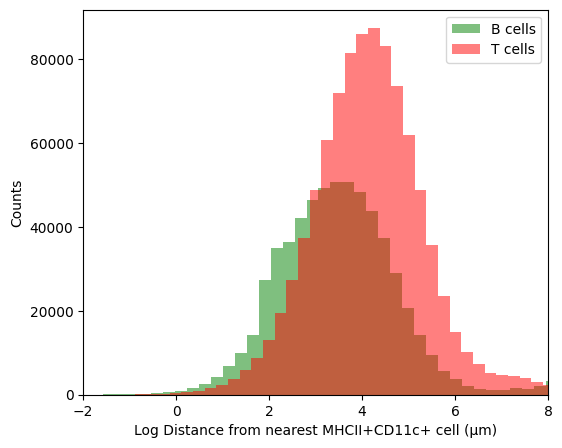

In [10]:
fig, axes = plt.subplots(figsize=(6,5))
axes.set_xlim(-2, 8)
axes.hist(np.log(distance_frame_b[f'{query_type_1}_{comp_type_1}_min_distances'].values), bins=50, color='g', alpha=0.5, label='B cells')
axes.hist(np.log(distance_frame_t[f'{query_type_2}_{comp_type_2}_min_distances'].values), bins=50, color='r', alpha=0.5, label='T cells')
axes.set_ylabel("Counts")
axes.set_xlabel(f"Log Distance from nearest {comp_type_1} cell (\u03bcm)")
plt.legend()
fig.savefig('figures/dendritic_distance_hist.svg', dpi=450, bbox_inches='tight')

plt.show()

In [11]:
# get mean and median frames for both b and t cells
region_filter=False
sample_stat_dict_b = {}
sample_stat_dict_t = {}
unique_sample_names = np.unique(distance_frame_b['src_image'])
for sample_name in unique_sample_names:
    stat_dict_t = {}
    stat_dict_b = {}
    
    subset_b_frame = distance_frame_b[distance_frame_b['src_image']==sample_name]
    subset_t_frame = distance_frame_t[distance_frame_t['src_image']==sample_name]
    
    # filter with region names and see how results_change
    if region_filter:
        subset_b_frame = subset_b_frame[subset_b_frame['merged_region_name'].isin(tls_feature_frame['region_names'])]
        subset_t_frame = subset_t_frame[subset_t_frame['merged_region_name'].isin(tls_feature_frame['region_names'])]
    
    median_b_dist = np.median(subset_b_frame[f'{query_type_1}_{comp_type_1}_min_distances'])
    mean_b_dist = np.mean(subset_b_frame[f'{query_type_1}_{comp_type_1}_min_distances'])
    
    median_t_dist = np.median(subset_t_frame[f'{query_type_2}_{comp_type_2}_min_distances'])
    mean_t_dist = np.mean(subset_t_frame[f'{query_type_2}_{comp_type_2}_min_distances'])
    
    stat_dict_t['median_dist'] = median_t_dist
    stat_dict_t['mean_dist'] = mean_t_dist
    
    stat_dict_b['median_dist'] = median_b_dist
    stat_dict_b['mean_dist'] = mean_b_dist
    
    sample_stat_dict_b[sample_name] = stat_dict_b
    sample_stat_dict_t[sample_name] = stat_dict_t
    
sample_b_frame = pd.DataFrame(sample_stat_dict_b).T
sample_t_frame = pd.DataFrame(sample_stat_dict_t).T

In [12]:
sns_dist_frame = pd.DataFrame()

b_dist = np.copy(sample_b_frame['median_dist'].values)
t_dist = np.copy(sample_t_frame['median_dist'].values)

b_names = np.array(['CD20+']*len(b_dist))
t_names = np.array(['CD8+']*len(t_dist))

sns_dist_frame['median_distance'] = np.concatenate([t_dist, b_dist], axis=0)
sns_dist_frame['cell_type'] = np.concatenate([t_names, b_names], axis=0)

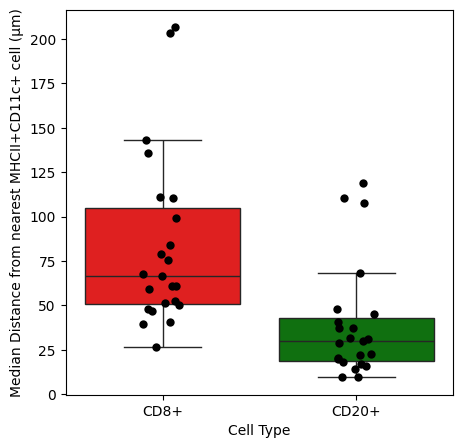

In [13]:
fig, axes = plt.subplots(figsize=(5,5))
sns.boxplot(data=sns_dist_frame, x='cell_type', y='median_distance', hue='cell_type', palette={'CD8+': 'r', 'CD20+': 'g'},showfliers=False, ax=axes)
sns.stripplot(data=sns_dist_frame, x='cell_type', y='median_distance', color='black', size=6, ax=axes)
plt.gca().set_xlabel('Cell Type')
plt.gca().set_ylabel(f'Median Distance from nearest {comp_type_1} cell (\u03bcm)')
fig.savefig('figures/dendritic_distance_t_b.svg', dpi=450, bbox_inches='tight')


In [14]:
# here drop all dendritic cells that do not belong to neighborhood 0
neighbor_adata = neighbor_adata[~np.logical_and((neighbor_adata.obs[type_key]=="MHCII+CD11c+"), (neighbor_adata.obs[cluster_label]!='0'))]

In [15]:
neighbor_adata.obsm['spatial'] = neighbor_adata.obs[[x_key, y_key]].to_numpy()

/tmp/ipykernel_31802/1876591444.py:1: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  neighbor_adata.obsm['spatial'] = neighbor_adata.obs[[x_key, y_key]].to_numpy()


In [16]:
# Assign 'src_image' as the library ID
neighbor_adata.obs['library_id'] = neighbor_adata.obs['src_image'].astype('category')

# neighbor_adata adata.uns['spatial'] with dummy image data per library
neighbor_adata.uns['spatial'] = {
    lib_id: {
        "images": {},  # required structure, even if empty
        "scalefactors": {},  # optional if not using scale-aware plots
    }
    for lib_id in neighbor_adata.obs['library_id'].unique()
}

In [17]:
# build a summary dataframe for each sample
region_filter=False
radius_val=100
# unique_sample_names = np.unique(filtered_cell_adata.obs[sample_key])
unique_sample_names = np.unique(neighbor_adata.obs[sample_key].values)
sample_stat_dict = {}
overall_frame_list = []
for sample_of_interest in tqdm(unique_sample_names):
    stat_dict = {}
    # sample_cell_adata = filtered_cell_adata[filtered_cell_adata.obs[sample_key]==sample_of_interest]
    sample_neighbor_adata = neighbor_adata[neighbor_adata.obs[sample_key]==sample_of_interest]
    sample_outcome = sample_neighbor_adata.obs.iloc[0][outcome_key]
    # sample_outcome = sample_cell_adata.obs.iloc[0][outcome_key]
    
    if sample_outcome not in outcomes_of_interest:
        continue
        
    if region_filter:
        sample_neighbor_adata = sample_neighbor_adata[sample_neighbor_adata.obs['merged_region_name'].isin(tls_feature_frame['region_names'])]
    
    sq.gr.spatial_neighbors(sample_neighbor_adata, library_key='library_id', coord_type='generic', radius=radius_val)
    connectivities = sample_neighbor_adata.obsp['spatial_connectivities'].tocoo()
    type_vector = sample_neighbor_adata.obs[type_key].values

    # Step 3: Identify relevant cell indices
    mhcii_idx = np.where(type_vector == 'MHCII+CD11c+')[0]
    cd8_idx = set(np.where(type_vector == 'CD8+')[0])
    cd20_idx = set(np.where(type_vector == 'CD20+')[0])

    neighbors_dict = defaultdict(list)

    # Collect neighbors for each cell
    for i, j in zip(connectivities.row, connectivities.col):
        neighbors_dict[i].append(j)

    # Step 5: For each MHCII+CD11c+ cell, count CD8+ and CD20+ neighbors
    results = []

    for cell_id in mhcii_idx:
        neighbors = neighbors_dict[cell_id]
        cd8_neighbors = sum(1 for n in neighbors if n in cd8_idx)
        cd20_neighbors = sum(1 for n in neighbors if n in cd20_idx)

        results.append({
            'cell_id': cell_id,
            'CD8+_neighbors': cd8_neighbors,
            'CD20+_neighbors': cd20_neighbors
        })

    # Convert to DataFrame for easier viewing
    interaction_df = pd.DataFrame(results)
    keep_rows = np.nonzero(np.sum(interaction_df[['CD8+_neighbors', 'CD20+_neighbors']].values, axis=1)!=0)[0]
    rows_to_drop_t = np.nonzero(interaction_df[['CD8+_neighbors']]==0)[0]
    rows_to_drop_b = np.nonzero(interaction_df[['CD20+_neighbors']]==0)[0]
    combined_rows = np.concatenate([rows_to_drop_t, rows_to_drop_b])
    rows_to_drop = np.unique(combined_rows)
    overall_rows = np.arange(0, interaction_df.shape[0])
    rows_to_keep = np.setdiff1d(overall_rows, rows_to_drop)

    
    filtered_interaction_frame = interaction_df.iloc[rows_to_keep]
    
    median_b = np.median(filtered_interaction_frame['CD20+_neighbors'].values)
    median_t = np.median(filtered_interaction_frame['CD8+_neighbors'].values)
    mean_b = np.mean(filtered_interaction_frame['CD20+_neighbors'].values)
    mean_t = np.mean(filtered_interaction_frame['CD8+_neighbors'].values)
    
    stat_dict['Median CD20+ Counts'] = median_b
    stat_dict['Mean CD20+ Counts'] = mean_b
    stat_dict['Median CD8+ Counts'] = median_t
    stat_dict['Mean CD8+ Counts'] = mean_t
    
    sample_stat_dict[sample_of_interest] = stat_dict
    
    # make an overall view and sample?
    overall_frame_list.append(filtered_interaction_frame)


  0%|                                                                                            | 0/23 [00:00<?, ?it/s]/home/hughm/anaconda3/envs/sq_env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
  4%|███▋                                                                                | 1/23 [00:11<04:09, 11.34s/it]/home/hughm/anaconda3/envs/sq_env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
  9%|███████▎                                                                            | 2/23 [00:13<01:58,  5.66s/it]/home/hughm/anaconda3/envs/sq_env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing vi

In [18]:
# we should normalize the density values here
norm_radius = radius_val
radius_sq = norm_radius**2
density_area = np.pi*radius_sq
density_area

31415.926535897932

In [19]:
sample_stat_frame = pd.DataFrame(sample_stat_dict).T


In [20]:
sample_stat_frame['Median CD20+ density'] = sample_stat_frame['Median CD20+ Counts'].values/density_area
sample_stat_frame['Median CD8+ density'] = sample_stat_frame['Median CD8+ Counts'].values/density_area

In [21]:
sns_sample_frame = pd.DataFrame()
b_counts = np.copy(sample_stat_frame['Median CD20+ Counts'].values)
t_counts = np.copy(sample_stat_frame['Median CD8+ Counts'].values)
b_ids = np.array(['CD20+']*len(b_counts))
t_ids = np.array(['CD8+']*len(t_counts))
sns_sample_frame['median_cell_count'] = np.concatenate([t_counts, b_counts], axis=0)
sns_sample_frame['cell_type'] = np.concatenate([t_ids, b_ids], axis=0)

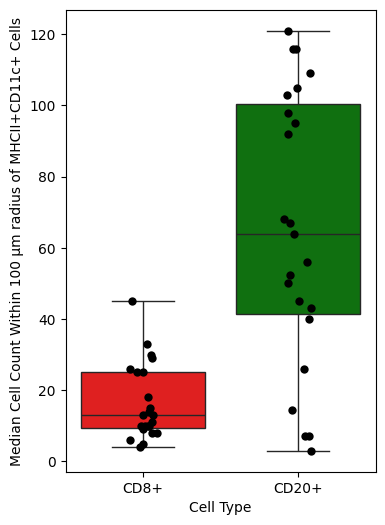

In [22]:
fig, axes = plt.subplots(figsize=(4,6))
sns.boxplot(data=sns_sample_frame, x='cell_type', y='median_cell_count', hue='cell_type', palette={'CD8+': 'r', 'CD20+': 'g'},showfliers=False, ax=axes)
sns.stripplot(data=sns_sample_frame, x='cell_type', y='median_cell_count', color='black', size=6, ax=axes)
plt.gca().set_xlabel('Cell Type')
plt.gca().set_ylabel(f'Median Cell Count Within 100 µm radius of {comp_type_1} Cells')
fig.savefig(f'figures/sample_level_pairwise_cell_count_comparison_dendritic_rcn_0_only.svg', dpi=450, bbox_inches='tight')

